# LSTM vs GRU 성능 & 속도 비교

**IMDB 영화 리뷰 감성 분류** 문제를 통해 LSTM과 GRU 두 모델을 직접 비교해보겠습니다 !

> **실행 방법: Colab 상단 메뉴에서 `연결 > 런타임 유형 변경 > T4 GPU`로 설정한 뒤, 각 셀을 위에서부터 순서대로 실행해주세요.**

## 0. 실습 개요

**태스크**: IMDB 영화 리뷰가 긍정(1)인지 부정(0)인지 분류하는 이진 분류 문제

임베딩 층(Embedding) + 순환층(LSTM 또는 GRU) + 출력층(Dense) 구조를 동일하게 맞추고, 순환층만 LSTM ↔ GRU로 바꿔서 공정하게 비교.

## 1단계. 라이브러리 불러오기 및 GPU 확인

먼저 필요한 라이브러리를 불러오고, GPU가 잘 연결되어 있는지 확인합니다.
GPU가 없으면 학습 시간이 훨씬 오래 걸리니 꼭 확인해주세요!

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense

# 재현성을 위한 시드 고정
tf.random.set_seed(42)
np.random.seed(42)

# GPU 사용 가능 여부 확인
print("사용 가능한 장치:")
print(tf.config.list_physical_devices('GPU'))
if len(tf.config.list_physical_devices('GPU')) == 0:
    print("⚠️ GPU가 연결되어 있지 않습니다. 연결 > 런타임 유형 변경 > T4 GPU로 설정해주세요.")
else:
    print("✅ GPU 연결 확인 완료!")


사용 가능한 장치:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ GPU 연결 확인 완료!


## 2단계. 데이터 준비 (IMDB 영화 리뷰)

*Keras에는 IMDB 영화 리뷰 5만 건이 내장되어 있습니다.
단어는 이미 정수 인덱스로 변환되어 있어서 바로 학습에 사용할 수 있습니다.

- `vocab_size`: 등장 빈도 상위 몇 개의 단어만 사용할지 (나머지는 무시)
   
   *keras에 있는 모든 단어를 사용하기에는 시간이 너무 오래걸림
- `max_len`: 리뷰 하나당 최대 단어 길이 (넘으면 자르고, 모자라면 0으로 채움 → padding)
   
   *문장 길이 맞추기

In [2]:
# 하이퍼파라미터 설정
vocab_size = 10000    # 상위 10,000개 단어만 사용
max_len = 200         # 리뷰 하나당 최대 200단어
embedding_dim = 32    # 임베딩 벡터 차원

# 데이터 로드 (처음 실행 시 자동 다운로드됨)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"학습 데이터 개수: {len(x_train)}")
print(f"테스트 데이터 개수: {len(x_test)}")
print(f"첫 번째 리뷰(정수 인덱스, 앞 20개): {x_train[0][:20]}")
print(f"첫 번째 리뷰의 라벨: {y_train[0]} (1=긍정, 0=부정)")

# 리뷰 길이를 max_len으로 통일 (padding)
x_train = pad_sequences(x_train, maxlen=max_len, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post', truncating='post')

print(f"\npadding 후 shape: {x_train.shape}  (샘플 수, 시퀀스 길이)")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
학습 데이터 개수: 25000
테스트 데이터 개수: 25000
첫 번째 리뷰(정수 인덱스, 앞 20개): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
첫 번째 리뷰의 라벨: 1 (1=긍정, 0=부정)

padding 후 shape: (25000, 200)  (샘플 수, 시퀀스 길이)


## 3단계. 모델 설계

**공정한 비교**를 위해 두 모델은 딱 한 층(LSTM ↔ GRU)만 다르고 나머지 구조는 동일합니다.

```
입력 시퀀스
   ↓
Embedding (단어 → 벡터)
   ↓
LSTM 또는 GRU (시퀀스 정보 요약)
   ↓
Dense (이진 분류, sigmoid)
   ↓
출력 (0~1 사이 확률)
```

### 3-2. LSTM 셀 직접 구현해보기


LSTM은 셀 상태 $c_t$와 은닉 상태 $h_t$ 두 개를 함께 관리하고, 게이트가 3개(망각/입력/출력)입니다.

$$f_t = \sigma(x_t W_f + h_{t-1} U_f + b_f) \quad \text{(망각 게이트)}$$
$$i_t = \sigma(x_t W_i + h_{t-1} U_i + b_i) \quad \text{(입력 게이트)}$$
$$o_t = \sigma(x_t W_o + h_{t-1} U_o + b_o) \quad \text{(출력 게이트)}$$
$$\tilde c_t = \tanh(x_t W_c + h_{t-1} U_c + b_c) \quad \text{(후보 셀상태)}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde c_t \quad \text{(셀 상태 갱신)}$$
$$h_t = o_t \odot \tanh(c_t) \quad \text{(은닉 상태 갱신)}$$

In [7]:
class LSTMCellCustom(tf.keras.layers.Layer):

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = [units, units] # LSTM은 상태가 2개(h, c)이므로 리스트로 지정
        self.output_size = units

    def build(self, input_shape):
        input_dim = input_shape[-1]
        u = self.units

        # --- 망각 게이트(f_t) ---
        self.Wf = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wf')
        self.Uf = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uf')
        self.bf = self.add_weight(shape=(u,), initializer='ones', name='bf')  # 초기값 1: 학습 초반 정보를 잘 유지하도록

        # --- 입력 게이트(i_t) ---
        self.Wi = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wi')
        self.Ui = self.add_weight(shape=(u, u), initializer='orthogonal', name='Ui')
        self.bi = self.add_weight(shape=(u,), initializer='zeros', name='bi')

        # --- 출력 게이트(o_t) ---
        self.Wo = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wo')
        self.Uo = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uo')
        self.bo = self.add_weight(shape=(u,), initializer='zeros', name='bo')

        # --- 후보 셀상태(c_tilde) ---
        self.Wc = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wc')
        self.Uc = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uc')
        self.bc = self.add_weight(shape=(u,), initializer='zeros', name='bc')

        super().build(input_shape)

    def call(self, inputs, states):
        # states[0]: 이전 은닉상태 h_{t-1},  states[1]: 이전 셀상태 c_{t-1}
        x_t = inputs
        h_prev, c_prev = states

        # 식을 참고해서 코드 작성해주세요
        f_t = tf.sigmoid(tf.matmul(x_t, self.Wf) + tf.matmul(h_prev, self.Uf) + self.bf)
        i_t = tf.sigmoid(tf.matmul(x_t, self.Wi) + tf.matmul(h_prev, self.Ui) + self.bi)
        o_t = tf.sigmoid(tf.matmul(x_t, self.Wo) + tf.matmul(h_prev, self.Uo) + self.bo)
        c_tilde = tf.tanh(tf.matmul(x_t, self.Wc) + tf.matmul(h_prev, self.Uc) + self.bc)

        c_t = f_t * c_prev + i_t * c_tilde
        h_t = o_t * tf.tanh(c_t)

        return h_t, [h_t, c_t]

<details>
<summary> HINT </summary>

tf.sigmoid, tf.matmul, tf.tanh 활용해서 식을 작성해주시면 됩니다 !

</details>

### 3-1. GRU 셀 직접 구현해보기

앞서 배운 GRU 수식을 그대로 코드로 옮기면 다음과 같습니다.

$$r_t = \sigma(x_t W_r + h_{t-1} U_r + b_r) \quad \text{(리셋 게이트)}$$
$$z_t = \sigma(x_t W_z + h_{t-1} U_z + b_z) \quad \text{(업데이트 게이트)}$$
$$\tilde h_t = \tanh(x_t W_h + (r_t \odot h_{t-1}) U_h + b_h) \quad \text{(후보 은닉상태)}$$
$$h_t = (1-z_t) \odot h_{t-1} + z_t \odot \tilde h_t \quad \text{(최종 은닉상태)}$$

`tf.keras.layers.RNN`이 시간 축(time step)을 따라 이 셀을 자동으로 반복 호출해줍니다.
우리는 **한 시점(time step)에서 무슨 계산이 일어나는지**만 `call()` 안에 정의하면 됩니다.

In [8]:
class GRUCellCustom(tf.keras.layers.Layer):

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.state_size = units
        self.output_size = units

    def build(self, input_shape):
        input_dim = input_shape[-1]
        u = self.units

        # --- 리셋 게이트(r_t) 파라미터: W_r, U_r, b_r ---
        self.Wr = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wr')
        self.Ur = self.add_weight(shape=(u, u), initializer='orthogonal', name='Ur')
        self.br = self.add_weight(shape=(u,), initializer='zeros', name='br')

        # --- 업데이트 게이트(z_t) 파라미터: W_z, U_z, b_z ---
        self.Wz = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wz')
        self.Uz = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uz')
        self.bz = self.add_weight(shape=(u,), initializer='zeros', name='bz')

        # --- 후보 은닉상태(h_tilde) 파라미터: W_h, U_h, b_h ---
        self.Wh = self.add_weight(shape=(input_dim, u), initializer='glorot_uniform', name='Wh')
        self.Uh = self.add_weight(shape=(u, u), initializer='orthogonal', name='Uh')
        self.bh = self.add_weight(shape=(u,), initializer='zeros', name='bh')

        super().build(input_shape)

    def call(self, inputs, states):
        # inputs: 현재 시점의 입력 x_t,  states[0]: 이전 은닉상태 h_{t-1}
        x_t = inputs
        h_prev = states[0]

        # 식을 참고해서 코드 작성해주세요.
        r_t = tf.sigmoid(tf.matmul(x_t, self.Wr) + tf.matmul(h_prev, self.Ur) + self.br)
        z_t = tf.sigmoid(tf.matmul(x_t, self.Wz) + tf.matmul(h_prev, self.Uz) + self.bz)

        h_tilde = tf.tanh(
            tf.matmul(x_t, self.Wh)
            + tf.matmul(r_t * h_prev, self.Uh)
            + self.bh
        )

        h_t = (1 - z_t) * h_prev + z_t * h_tilde

        return h_t, [h_t]

### 3-3. 모델 불러오기

실제로는 tensorflow에서 LSTM과 GRU를 제공합니다. 라이브러리 호출해서 비교해보겠습니다.

In [9]:
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU

RNN_units = 32
batch_size = 64
epochs = 10

# 모델 생성 함수 정의
def build_model(cell_type):
    model = Sequential()
    # 1) 단어 임베딩: 입력 시퀀스를 EMB_DIM 차원 벡터로 변환
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=embedding_dim,
                        input_length=max_len))
    # 2) 순환 셀 추가
    if cell_type == 'RNN':
        model.add(SimpleRNN(RNN_units))
    elif cell_type == 'LSTM':
        model.add(LSTM(RNN_units))
    elif cell_type == 'GRU':
        model.add(GRU(RNN_units))
    # 3) 출력층: sigmoid 활성화로 이진 분류
    model.add(Dense(1, activation='sigmoid'))

    # 4) 컴파일: Adam 옵티마이저, binary_crossentropy 손실, 정확도 지표
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

**참고**: `summary()` 결과에서 `Total params`를 비교해보세요.
같은 `hidden_units`를 사용해도 LSTM은 게이트(가중치 세트)가 4개(f, i, o, c_tilde), GRU는 3개(r, z, h_tilde)이기 때문에
**LSTM의 파라미터 수가 GRU보다 약 1.33배(≈4/3) 많습니다.**
(순환층 파라미터 수: LSTM = 4 × (게이트당 파라미터), GRU = 3 × (게이트당 파라미터))

> 💡 `tf.keras.layers.LSTM` / `GRU` 같은 내장 레이어는 내부적으로 cuDNN 가속을 사용해서
> 우리가 만든 커스텀 셀보다 학습 속도가 훨씬 빠릅니다. 즉, 이번 실습의 속도 비교는
> **"직접 구현한 두 모델끼리의 상대적인 속도 차이"**를 보는 것이지, 실무에서 쓰는
> 최적화된 라이브러리 성능을 재는 것은 아니라는 점을 기억해주세요.

## 4단계. 모델 학습 및 결과 저장



In [10]:
# 에포크 타이머
import time

class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._epoch_start
        self.epoch_times.append(elapsed)

results = {}
for cell in ['RNN', 'LSTM', 'GRU']:
    print(f'▶ {cell} 모델 학습 시작...')
    model   = build_model(cell)
    timer = EpochTimer()

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=2,
        callbacks=[timer]
    )

    results[cell] = {
        'history': history.history,
        'avg_epoch_time': np.mean(timer.epoch_times),
    }

    print(f' {cell} → 평균 에폭 시간: {results[cell]["avg_epoch_time"]:.2f}초 ')

▶ RNN 모델 학습 시작...
Epoch 1/10
313/313 - 10s - 30ms/step - accuracy: 0.5059 - loss: 0.6943 - val_accuracy: 0.5182 - val_loss: 0.6921
Epoch 2/10
313/313 - 5s - 14ms/step - accuracy: 0.5938 - loss: 0.6561 - val_accuracy: 0.5184 - val_loss: 0.6993
Epoch 3/10
313/313 - 5s - 15ms/step - accuracy: 0.6886 - loss: 0.5282 - val_accuracy: 0.5106 - val_loss: 0.7720
Epoch 4/10
313/313 - 5s - 17ms/step - accuracy: 0.7349 - loss: 0.4248 - val_accuracy: 0.5114 - val_loss: 0.8717
Epoch 5/10
313/313 - 5s - 14ms/step - accuracy: 0.7591 - loss: 0.3904 - val_accuracy: 0.5156 - val_loss: 0.9135
Epoch 6/10
313/313 - 5s - 15ms/step - accuracy: 0.7790 - loss: 0.3646 - val_accuracy: 0.5136 - val_loss: 0.9499
Epoch 7/10
313/313 - 5s - 15ms/step - accuracy: 0.7742 - loss: 0.3669 - val_accuracy: 0.5126 - val_loss: 0.9743
Epoch 8/10
313/313 - 5s - 15ms/step - accuracy: 0.7925 - loss: 0.3517 - val_accuracy: 0.5006 - val_loss: 1.0358
Epoch 9/10
313/313 - 5s - 15ms/step - accuracy: 0.7787 - loss: 0.3663 - val_accuracy:

## 5단계. 학습 결과 시각화

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


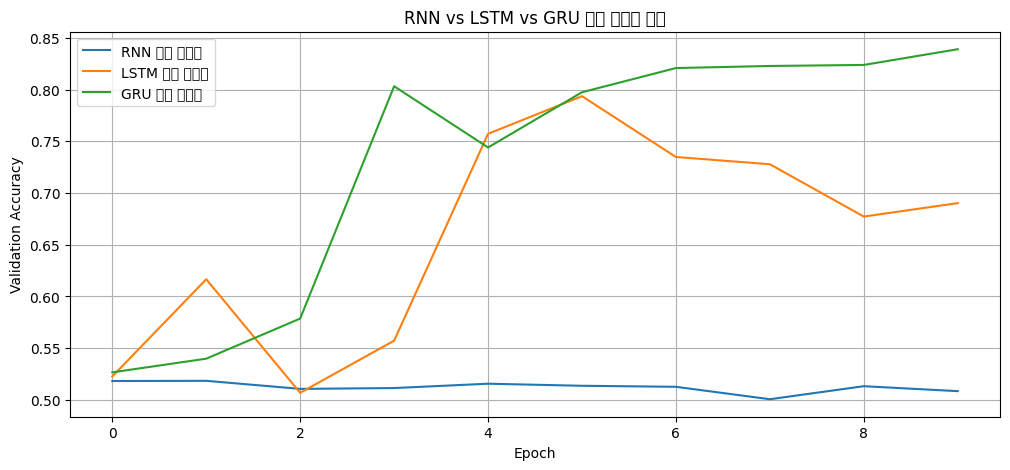

In [11]:
plt.figure(figsize=(12, 5))
for cell in results:
    plt.plot(results[cell]['history']['val_accuracy'],
             label=f'{cell} 검증 정확도')
plt.title('RNN vs LSTM vs GRU 검증 정확도 비교')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 6단계. 생각해봐주세요 !

실습 결과를 바탕으로 아래 질문에 답해보세요.

1. **정확도**: RNN, LSTM과 GRU 중 어느 모델의 테스트 정확도가 더 높나요? 그 차이가 통계적으로 유의미해 보이는 수준인가요, 아니면 오차 범위 수준인가요? 결과가 왜 이렇게 나왔는지 이유까지 설명해주세요.   
2. **속도**: 학습 시간과 추론 시간에서 GRU가 LSTM보다 빨랐나요? 그 차이가 통계적으로 유의미해 보이는 수준인가요, 아니면 오차 범위 수준인가요? 결과가 왜 이렇게 나왔는지 이유까지 설명해주세요.
3. **하이퍼파라미터 실험**: `RNN_units`나 `epochs`, `max_len`, 'batch_size' 등을  바꿔가며 다시 실행해보고, 결과가 어떻게 달라지는지 관찰해보세요.

**정답을 원하는 것이 아닙니다. 실습만 해보는 것이 아니라 결과에 대해 고민해보는 시간을 가지셨으면 좋겠습니다 ! 그럼 다들 BASE 활동 파이팅 하세요 😊**